In [3]:
# Membuat dua direktori yang diminta
!hdfs dfs -mkdir -p /user/Grimmer/ecommerce/raw
!hdfs dfs -mkdir -p /user/Grimmer/ecommerce/processed

# Menampilkan struktur direktori ecommerce beserta sub-direktorinya
!hdfs dfs -ls /user/Grimmer/ecommerce


Found 2 items
drwxr-xr-x   - Grimmer supergroup          0 2026-09-09 15:40 /user/Grimmer/ecommerce/processed
drwxr-xr-x   - Grimmer supergroup          0 2026-09-09 15:40 /user/Grimmer/ecommerce/raw


In [4]:
# Mengunggah 3 file CSV ke HDFS
!hdfs dfs -put transaksi_magelang.csv /user/Grimmer/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/Grimmer/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/Grimmer/ecommerce/raw/

# Verifikasi isi direktori beserta ukurannya
!hdfs dfs -ls /user/Grimmer/ecommerce/raw

Found 3 items
-rw-r--r--   1 Grimmer supergroup      12329 2026-09-09 15:49 /user/Grimmer/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 Grimmer supergroup      12154 2026-09-09 15:49 /user/Grimmer/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 Grimmer supergroup      12684 2026-09-09 15:49 /user/Grimmer/ecommerce/raw/transaksi_yogyakarta.csv


In [7]:
# Membaca Kembali dan Menggabungkan Data dari HDFS
import pandas as pd
import io
import subprocess

# Daftar nama file yang akan dibaca
files = ["transaksi_magelang.csv", "transaksi_yogyakarta.csv", "transaksi_semarang.csv"]
list_df = []

# Membaca data langsung dari HDFS menggunakan perintah cat 
for f in files:

    path_hdfs = f"/user/Grimmer/ecommerce/raw/{f}" 
    content = subprocess.check_output(["hdfs", "dfs", "-cat", path_hdfs]).decode('utf-8')
    df = pd.read_csv(io.StringIO(content))
    list_df.append(df)

# Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat(list_df, ignore_index=True)

# Menampilkan jumlah transaksi per kota
print("Jumlah transaksi per kota:")
print(df_gabungan['kota'].value_counts())

Jumlah transaksi per kota:
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [6]:
df_gabungan

,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang
...,...,...,...,...,...,...,...
595,SEM-2195,2026-08-31,Rumah Tangga,6,75000,Transfer Bank,Semarang
596,SEM-2196,2026-08-15,Kesehatan & Kecantikan,5,75000,Transfer Bank,Semarang
597,SEM-2197,2026-08-01,Makanan & Minuman,4,75000,E-Wallet,Semarang
598,SEM-2198,2026-08-05,Fashion,7,25000,Transfer Bank,Semarang


In [18]:
# 1. Menambahkan kolom total_pendapatan
df_gabungan['total_pendapatan'] = df_gabungan['unit_terjual'] * df_gabungan['harga_satuan']

# 2. Membuat tabel ringkasan per kota dan kategori
df_ringkasan = df_gabungan.groupby(['kota', 'kategori'])['total_pendapatan'].sum().reset_index()

# 3. Menyimpan kedua tabel sebagai CSV di disk lokal (VM)
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

# 4. Mengunggah ke folder processed di HDFS
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/Grimmer/ecommerce/processed/

# 5. Verifikasi hasil pengolahan
!hdfs dfs -ls /user/Grimmer/ecommerce/processed/


put: `/user/Grimmer/ecommerce/processed/data_gabungan_bersih.csv': File exists
put: `/user/Grimmer/ecommerce/processed/ringkasan_kota_kategori.csv': File exists
Found 2 items
-rw-r--r--   1 Grimmer supergroup      41257 2026-09-09 16:31 /user/Grimmer/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 Grimmer supergroup        530 2026-09-09 16:31 /user/Grimmer/ecommerce/processed/ringkasan_kota_kategori.csv



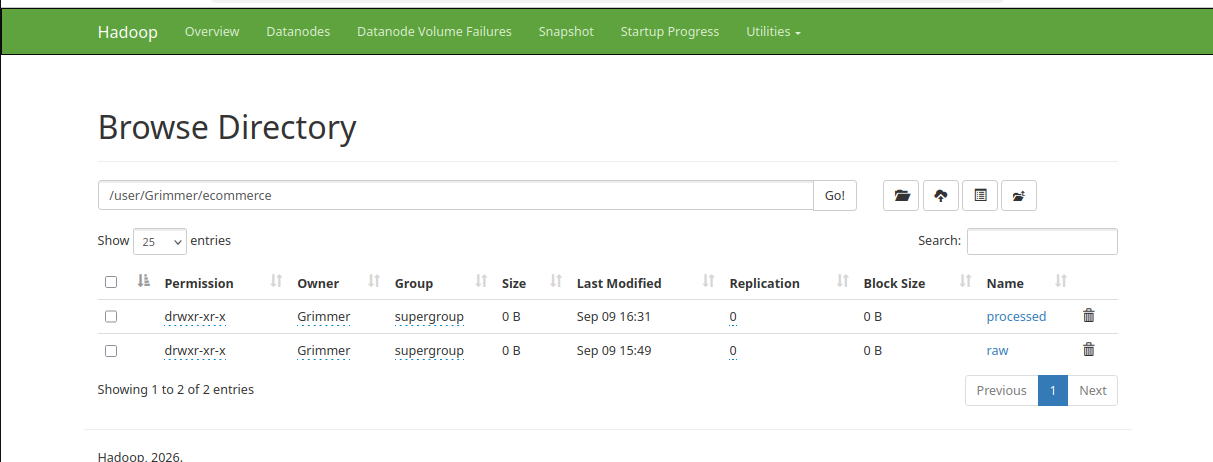



Refleksi:
Menyimpan data mentah secara terpisah dari data olahan di dalam HDFS merupakan strategi krusial untuk menjaga integritas dan keamanan arsitektur data, seperti yang telah diterapkan pada direktori ecommerce/raw dan ecommerce/processed. Dengan pemisahan ini, berkas CSV transaksi asli dapat dijaga sebagai sumber kebenaran tunggal (single source of truth) yang bersifat tetap (immutable), sehingga jika terjadi kesalahan dalam logika pemrosesan atau manipulasi kode, kita dapat dengan mudah melakukan proses hitung ulang (re-run) tanpa risiko kehilangan data asli. Selain itu, pemisahan struktur folder ini memudahkan pengelolaan data secara sistematis, di mana data mentah berfungsi menampung arsip transaksi harian secara utuh, sementara folder olahan menampung hasil ringkasan bisnis seperti total pendapatan per kota dan kategori. Praktik ini juga memastikan alur kerja rekayasa data menjadi lebih terstruktur dan siap digunakan untuk kebutuhan analisis selanjutnya.